In [1]:
import matplotlib.pyplot as plt, numpy as np, seaborn as sns, scipy.stats as stats, pandas as pd, os, glob
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
from scipy.stats import ttest_rel


### plot setting

In [2]:
# sns.set(context='paper')

# keep text editable in svg
plt.rcParams['svg.fonttype'] = 'none'

import matplotlib as mpl
# push ticks inward
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
# remove top and right splines
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False

In [3]:
df_clean = pd.read_csv('../../results/psychopy/all_subjs_v2.csv')

# subj_mapping = {'kahini': 1.1, 'renee': 1.11, 'daria': 1.111, 'sienna': 1.1111,
#                 'arnav': 2.1, 'christina': 2.11, 'albert': 2.111}
df_clean = df_clean[df_clean['subj'].between(2, 2.105, inclusive='both')].copy()
print(f'subjs: {df_clean["subj"].unique()}')

df_view = df_clean.drop_duplicates(subset=['condition', 'true_boundary'])
df_view[['subj', 'condition', 'true_boundary', 'target_boundary',
         'true_stim', 'stim_boundary_aligned', 'true_resp', 'resp_boundary_aligned']].head()

subjs: [2.1]


,subj,condition,true_boundary,target_boundary,true_stim,stim_boundary_aligned,true_resp,resp_boundary_aligned
960,2.1,curv_comp,-0.2,-0.2,-0.34,-0.14,-0.160,0.040
968,2.1,flat_comp,0.2,0.2,-0.10,-0.30,-0.232,-0.432
1008,2.1,baseline,0.0,0.0,0.22,0.22,0.044,0.044


### setup

In [36]:
patients = df_clean['subj'].unique().tolist()
n_pts = len(patients)
print(f'{n_pts} patients: {patients}')

bounds = df_clean['true_boundary'].unique().tolist()
print(f'bounds/contexts: {bounds}')

df_curv = df_clean[df_clean['condition'] == 'curv_comp'].copy()
df_base = df_clean[df_clean['condition'] == 'baseline'].copy()
df_flat = df_clean[df_clean['condition'] == 'flat_comp'].copy()

print(len(df_curv), len(df_base), len(df_flat))

3 patients: [2.1, 2.11, 2.111]
bounds/contexts: [-0.2, 0.2, 0.0]
240 240 240


In [37]:
# # choose what df
# def get_df(df_name):
#     if df_name == 'base':
#         return df_name, df_base
#     elif df_name == 'curv':
#         return df_name, df_curv
#     elif df_name == 'flat':
#         return df_name, df_flat

### plot setup

In [38]:
norm_ticks, norm_ticklabels = np.linspace(-.4, .4, 5), np.linspace(0, 1, 5)

### response distribution

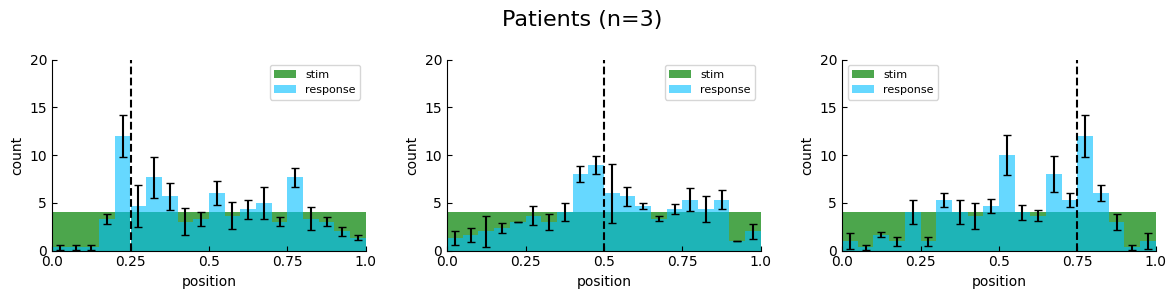

In [39]:

fig, axs = plt.subplots(1, 3, figsize=(12, 3))
axs, ax = axs.flatten(), 0

ba_bins = np.linspace(-.4, .4, 21)
bar_centers = np.linspace(-.38, .38, 20)

for cond in ['curv_comp', 'baseline', 'flat_comp']: # ordered

    df_cond = df_clean[df_clean['condition'] == cond].copy()

    # true stim distribution per subj (true_stim is already in -.4 to .4 space)
    stim_cts = []
    for subj, subj_df in df_cond.groupby('subj'):
        counts, _ = np.histogram(subj_df['true_stim'], bins=ba_bins)
        stim_cts.append(counts)
    stim_cts = np.array(stim_cts)
    mean_stim_cts = stim_cts.mean(axis=0)

    # response distribution per subj
    resp_cts = []
    for subj, subj_df in df_cond.groupby('subj'):
        counts, _ = np.histogram(subj_df['true_resp'], bins=ba_bins)
        resp_cts.append(counts)
    resp_cts = np.array(resp_cts)
    mean_resp_cts = resp_cts.mean(axis=0)
    sem_resp_cts = resp_cts.std(axis=0) / np.sqrt(resp_cts.shape[0])

    # plot
    axs[ax].bar(bar_centers, mean_stim_cts, width=.04, color='green', alpha=0.7, label='stim')
    axs[ax].bar(bar_centers, mean_resp_cts, width=.04, color='deepskyblue',
                yerr=sem_resp_cts, capsize=3, label='response', alpha=0.6)

    axs[ax].set(xlabel='position', ylabel='count', xlim=(-.4, .4), ylim=(0,20),
                xticks=norm_ticks, xticklabels=norm_ticklabels)
    # boundary
    axs[ax].axvline(df_cond['true_boundary'].iloc[0], color='black', linestyle='--')
    axs[ax].legend(fontsize=8)
    ax += 1

plt.suptitle(f'Patients (n={df_clean["subj"].nunique()})', fontsize=16)
plt.tight_layout()
plt.show()


## stim vs resp

### raw

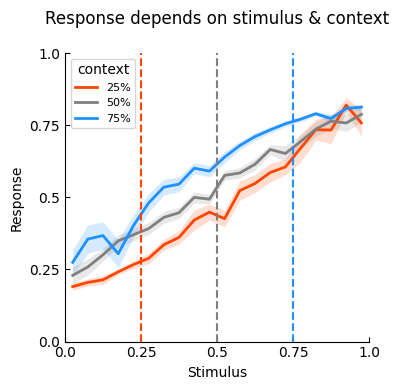

In [8]:
# plot stim vs resp, colored by condition (mean ± SEM)
fig, ax = plt.subplots(1, 1, figsize=(4,4))
colors = {'curv_comp': 'orangered', 'baseline': 'gray', 'flat_comp': 'dodgerblue'}
cond_label_map = {'curv_comp': '25%', 'baseline': '50%', 'flat_comp': '75%'}

for cond in ['curv_comp', 'baseline', 'flat_comp']:
    df_cond = df_clean[df_clean['condition'] == cond].copy()
    # Compute mean and SEM for each true_stim
    grouped = df_cond.groupby('true_stim')['true_resp']
    mean_resp = grouped.mean().sort_index()
    sem_resp = grouped.sem().sort_index()
    x = mean_resp.index.values
    y = mean_resp.values
    yerr = sem_resp.values
    # Plot mean line
    ax.plot(x, y, '-', linewidth=2, label=cond_label_map[cond], color=colors[cond])
    # Plot SEM band
    ax.fill_between(x, y - yerr, y + yerr, color=colors[cond], alpha=0.18, linewidth=0)

# add identity line
# ax.plot([-.4, .4], [-.4, .4], 'k--', alpha=0.3)
ax.axvline(-0.2, color='orangered', linewidth=1.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=1.5, linestyle='--')
ax.axvline(0.2, color='dodgerblue', linewidth=1.5, linestyle='--')

ax.set(title='Response depends on stimulus & context\n',
       xlabel='Stimulus', ylabel='Response',
       xticks=norm_ticks, xticklabels=norm_ticklabels,
       yticks=norm_ticks, yticklabels=norm_ticklabels,
       xlim=(-.4, .4), ylim=(-.4, .4))
# ax.set(xticks=norm_ticks, xticklabels=norm_ticklabels,
#        yticks=norm_ticks, yticklabels=norm_ticklabels,
#        xlim=(-.4, .4), ylim=(-.4, .4))
ax.tick_params(axis='both', direction='in')

ax.legend(fontsize=8, title='context')
plt.tight_layout()
# plt.savefig('../../figs/ccn/beh-pt-stim_vs_resp.svg', format='svg')
plt.show()


### boundary-aligned

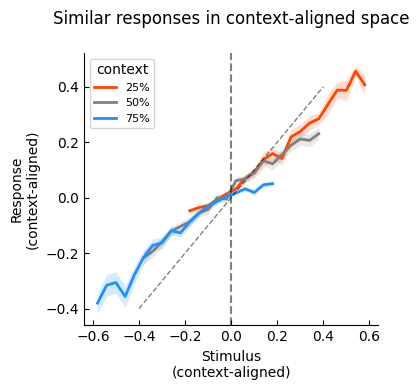

In [9]:
# plot stim vs resp, colored by condition (mean ± SEM)
fig, ax = plt.subplots(1, 1, figsize=(4,4))
colors = {'curv_comp': 'orangered', 'baseline': 'gray', 'flat_comp': 'dodgerblue'}
cond_label_map = {'curv_comp': '25%', 'baseline': '50%', 'flat_comp': '75%'}

for cond in ['curv_comp', 'baseline', 'flat_comp']:
    df_cond = df_clean[df_clean['condition'] == cond].copy()
    grouped = df_cond.groupby('stim_boundary_aligned')['resp_boundary_aligned']
    mean_resp = grouped.mean().sort_index()
    sem_resp = grouped.sem().sort_index()
    x = mean_resp.index.values
    y = mean_resp.values
    yerr = sem_resp.values
    ax.plot(x, y, '-', linewidth=2, label=cond_label_map[cond], color=colors[cond])
    ax.fill_between(x, y - yerr, y + yerr, color=colors[cond], alpha=0.18, linewidth=0)

ax.axvline(0, color='black', linewidth=1.5, linestyle='--', alpha=0.5)
# diagonal
ax.plot([-.4, .4], [-.4, .4], color = 'black', linewidth=1, linestyle='--', alpha=0.5)
ax.set(title='Similar responses in context-aligned space\n',
       xlabel='Stimulus\n(context-aligned)', ylabel='Response\n(context-aligned)')#,
    #    xticks=norm_ticks, xticklabels=np.linspace(-1.5, 1, 5),
    #    yticks=norm_ticks, yticklabels=np.linspace(-1, 1, 5),
    #    xlim=(-.4, .4), ylim=(-.4, .4))
ax.tick_params(axis='both', direction='in')

ax.legend(fontsize=8, title='context')
plt.tight_layout()
# plt.savefig('../../figs/ccn/beh-pt-stim_vs_resp_aligned.svg', format='svg')
plt.show()


In [10]:
# check range of stim_boundary_aligned and resp_boundary_aligned
print(f'stim_boundary_aligned range: {df_clean["stim_boundary_aligned"].min()} to {df_clean["stim_boundary_aligned"].max()}')
print(f'resp_boundary_aligned range: {df_clean["resp_boundary_aligned"].min()} to {df_clean["resp_boundary_aligned"].max()}')

stim_boundary_aligned range: -0.58 to 0.58
resp_boundary_aligned range: -0.6 to 0.6


### rank-aligned

In [11]:
# # plot stim vs resp, colored by condition (mean ± SEM)
# fig, ax = plt.subplots(1, 1, figsize=(4,4))
# colors = {'curv_comp': 'orangered', 'baseline': 'gray', 'flat_comp': 'dodgerblue'}
# cond_label_map = {'curv_comp': '25%', 'baseline': '50%', 'flat_comp': '75%'}

# for cond in ['curv_comp', 'baseline', 'flat_comp']:
#     df_cond = df_clean[df_clean['condition'] == cond].copy()
#     grouped = df_cond.groupby('stim_ranks')['resp_ranks']
#     mean_resp = grouped.mean().sort_index()
#     sem_resp = grouped.sem().sort_index()
#     x = mean_resp.index.values
#     y = mean_resp.values
#     yerr = sem_resp.values
#     ax.plot(x, y, '-', linewidth=2, label=cond_label_map[cond], color=colors[cond])
#     ax.fill_between(x, y - yerr, y + yerr, color=colors[cond], alpha=0.18, linewidth=0)

# ax.axvline(40, color='black', linewidth=1.5, linestyle='--')
# ax.set(xlabel='stim rank', ylabel='resp rank')
# ax.legend(fontsize=8, title='context')
# plt.tight_layout()
# plt.show()


### visualizing reflection of compressed conditions

In [12]:
# # plot stim vs resp, colored by condition (mean ± SEM)
# fig, ax = plt.subplots(1, 1, figsize=(4,4))
# colors = {'curv_comp': 'orangered', 'baseline': 'gray', 'flat_comp': 'dodgerblue'}
# cond_label_map = {'curv_comp': '25%', 'baseline': '50%', 'flat_comp': '75%'}

# for cond in ['curv_comp', 'baseline', 'flat_comp']:
#     df_cond = df_clean[df_clean['condition'] == cond].copy()
#     if cond == 'flat_comp':
#         df_cond['stim_aligned_to_div'] = -df_cond['stim_aligned_to_div']
#         df_cond['resp_aligned_to_div'] = -df_cond['resp_aligned_to_div']
#     grouped = df_cond.groupby('stim_aligned_to_div')['resp_aligned_to_div']
#     mean_resp = grouped.mean().sort_index()
#     sem_resp = grouped.sem().sort_index()
#     x = mean_resp.index.values
#     y = mean_resp.values
#     yerr = sem_resp.values
#     ax.plot(x, y, '-', linewidth=2, label=cond_label_map[cond], color=colors[cond])
#     ax.fill_between(x, y - yerr, y + yerr, color=colors[cond], alpha=0.18, linewidth=0)

# # add identity line
# # ax.plot([-.4, .4], [-.4, .4], 'k--', alpha=0.3)
# ax.axvline(0, color='black', linewidth=1.5, linestyle='--', alpha=0.5)
# ax.set(xlabel='shape position\n(baseline-reflected)', ylabel='response position\n(baseline-reflected)',
#        xticks=norm_ticks, xticklabels=norm_ticklabels,
#        yticks=norm_ticks, yticklabels=norm_ticklabels,
#        xlim=(-.4, .4), ylim=(-.4, .4))

# ax.legend(fontsize=8, title='context')
# plt.tight_layout()
# plt.show()


### sigfic testing for context-alignment

In [13]:
# --- Context-shift alignment MSEs: within vs between ---
from itertools import combinations

all_within_MSEs = []  # per subjs
all_between_MSEs = []  # per subjs

for subj in patients:
    subjs_df = df_clean[df_clean['subj'] == subj]
    # Compute 3 within-context MSEs (stim_boundary_aligned vs resp_aligned for each context)
    subjs_within_MSEs = []
    for bound in bounds:
        context_df = subjs_df[subjs_df['true_boundary'] == bound]
        mse = np.mean((context_df['stim_boundary_aligned'].values - context_df['resp_boundary_aligned'].values) ** 2)
        subjs_within_MSEs.append(mse)
    all_within_MSEs.append(np.mean(subjs_within_MSEs))

    # Compute between-context MSEs (pairwise resp_boundary_aligned between contexts)
    subj_between_MSEs = []
    for bound1, bound2 in combinations(bounds, 2):
        c1_df = subjs_df[subjs_df['true_boundary'] == bound1]
        c2_df = subjs_df[subjs_df['true_boundary'] == bound2]

        # retain resps only for overlapping stim_boundary_aligned vals between the two contexts
        common_stim_boundary_aligned = np.intersect1d(c1_df['stim_boundary_aligned'].values, c2_df['stim_boundary_aligned'].values)
        c1_overlap = c1_df[c1_df['stim_boundary_aligned'].isin(common_stim_boundary_aligned)].sort_values('stim_boundary_aligned')
        c2_overlap = c2_df[c2_df['stim_boundary_aligned'].isin(common_stim_boundary_aligned)].sort_values('stim_boundary_aligned')
        
        # avg over duplicated stim_boundary_aligned vals
        c1_mean = c1_overlap.groupby('stim_boundary_aligned')['resp_boundary_aligned'].mean()
        c2_mean = c2_overlap.groupby('stim_boundary_aligned')['resp_boundary_aligned'].mean()

        # Now align indices and compute MSE
        common_index = c1_mean.index.intersection(c2_mean.index)
        mse = np.mean((c1_mean.loc[common_index] - c2_mean.loc[common_index]) ** 2)

        subj_between_MSEs.append(mse)
    all_between_MSEs.append(np.mean(subj_between_MSEs))

all_within_MSEs = np.array(all_within_MSEs)
all_between_MSEs = np.array(all_between_MSEs)

print('Subjs\' within-context MSEs:', all_within_MSEs)
print('Subjs\' between-context MSEs:', all_between_MSEs)
print('Mean within:', all_within_MSEs.mean(), 'Mean between:', all_between_MSEs.mean())

Subjs' within-context MSEs: [0.02753787 0.01273207 0.01246187 0.0179154  0.02151547 0.01331107
 0.01688033]
Subjs' between-context MSEs: [0.0020155  0.00480343 0.00341467 0.0056666  0.00296572 0.01091702
 0.00753967]
Mean within: 0.017479152380952382 Mean between: 0.005331803174603175


Paired t-test: t=4.206, p=0.00565


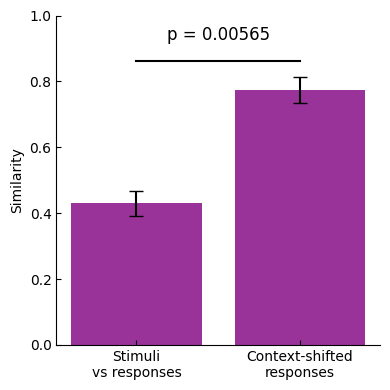

In [14]:
# --- Bar plot: Within vs Between context alignment MSEs ---
t_stat, p_val = ttest_rel(all_within_MSEs, all_between_MSEs)
print(f'Paired t-test: t={t_stat:.3f}, p={p_val:.3g}')
fig, axs = plt.subplots(1, 1, figsize=(4, 4))
axs = [axs]  # flatten for consistent indexing
ax = 0

alpha = 50  # adjust as needed for your scale
test_means = np.exp(-alpha * all_within_MSEs)
test_sds = np.exp(-alpha * all_between_MSEs)

means = [test_means.mean(), test_sds.mean()]
sems = [test_means.std() / np.sqrt(len(test_means)),
        test_sds.std() / np.sqrt(len(test_sds))]

bars = axs[ax].bar([0, 1], means, yerr=sems, capsize=5, color=['purple', 'purple'], alpha=0.8)
axs[ax].set(xticks=[0, 1], xticklabels=['Stimuli\nvs responses', 'Context-shifted\nresponses'], ylabel='Similarity')
axs[ax].grid(False)  # Remove grid
# axs[ax].set_title('Responses are significantly aligned to context')

# Draw only horizontal line connecting bar tops
bar_tops = [means[0] + sems[0], means[1] + sems[1]]
line_y = max(bar_tops) + 0.05
axs[ax].plot([0, 1], [line_y, line_y], color='black', linewidth=1.5)

# Place stars just above the line, within plot area
axs[ax].text(0.5, line_y + 0.05, f'p = {p_val:.3g}', ha='center', va='bottom', fontsize=12)

# Increase ylim if needed to fit stars
axs[ax].set_ylim(0, line_y + 0.005)
axs[ax].set_ylim(0, 1)

plt.tight_layout()
# plt.savefig('../../figs/ccn/beh-pt-context_similarity.svg', format='svg')
plt.show()

In [15]:
# fig, axs = plt.subplots(1, 3, figsize=(12, 3))
# axs, ax = axs.flatten(), 0

# # groupby condition
# for cond in ['curv_comp', 'baseline', 'flat_comp']: # ordered
    
#     df_cond = df_clean[df_clean['condition'] == cond].copy()
    
#     axs[ax].plot(df_cond['stim_pos'], df_cond['resp_ranks'], 'o', markersize=3)
#     axs[ax].axvline(df_cond['div_pos_aligned'].iloc[0], color='black', linestyle='--')
#     # axs[ax].axhline(df_cond['div_pos_aligned'].iloc[0], color='black', linestyle='--')
            
#     axs[ax].set(title=f'{cond}', xlabel='stim position', ylabel='response rank',
#                 xticks=norm_ticks, xticklabels=norm_ticklabels)
#     ax += 1

# plt.suptitle(f'STim vs Resp Rank', y=1.05)
# plt.show()

In [16]:
# fig, axs = plt.subplots(1, 3, figsize=(12, 3))
# axs, ax = axs.flatten(), 0

# for cond in ['curv', 'base', 'flat']:

#     # get df condition
#     df_name, df_analysis = get_df(cond)

#     # compute abs. rank error
#     df_analysis['abs_rank_err'] = np.abs(df_analysis['resp_ranks'] - df_analysis['stim_ranks'])
#     # compute median abs. rank error
#     median_by_stim = df_analysis.groupby('stim_pos', as_index=False)['abs_rank_err'].median().sort_values('stim_pos')

#     axs[ax].scatter(df_analysis['stim_pos'], df_analysis['abs_rank_err'], alpha=0.5, s=20)
#     axs[ax].plot(median_by_stim['stim_pos'], median_by_stim['abs_rank_err'], color='crimson', lw=2)

#     axs[ax].axvline(df_analysis['div_pos_aligned'].iloc[0], color='black', linestyle='--')
#     axs[ax].set(title=df_name,
#                 xlabel='Stim. Pos.', xlim=(-.4, .4), xticks=norm_ticks, xticklabels=norm_ticklabels,
#                 ylabel='|Response Rank Err.|')
#     ax += 1

# plt.tight_layout()
# plt.show()